In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, math, pickle, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size': 12,
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'axes.grid': True,
    'grid.alpha': 0.3,
})

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Mounted at /content/drive
Device: cuda
GPU: Tesla T4


In [2]:
DATA_DIR = '/content/drive/MyDrive/LSTGAN_Data/results'

CKPT_PATH  = os.path.join(DATA_DIR, 'best_lstgan.pt')
GRAPH_FILE = os.path.join(DATA_DIR, 'adj_mx_bay.pkl')
TRAIN_FILE = os.path.join(DATA_DIR, 'train_5min.pkl')
VAL_FILE   = os.path.join(DATA_DIR, 'val_5min.pkl')
TEST_FILE  = os.path.join(DATA_DIR, 'test_5min.pkl')

for name, path in [('Checkpoint', CKPT_PATH), ('Graph', GRAPH_FILE),
                    ('Train', TRAIN_FILE), ('Val', VAL_FILE), ('Test', TEST_FILE)]:
    exists = os.path.exists(path)
    print(f'  {name:12s}: {"✓" if exists else "✗ MISSING"} {path}')

NUM_SENSORS      = 325
STEPS_PER_HOUR   = 12
STEPS_PER_DAY    = 288

WEEKLY_WINDOW    = 2016
DAILY_WINDOW     = 288
HOURLY_WINDOW    = 12
FORECAST_HORIZON = 12
EVAL_HORIZONS    = [3, 6, 12]  # H3=15min, H6=30min, H12=60min

# ─── Model Architecture ───
WEEKLY_IN_CHANNELS  = 3;  WEEKLY_OUT_CHANNELS  = 16
DAILY_IN_CHANNELS   = 3;  DAILY_OUT_CHANNELS   = 8
HOURLY_IN_CHANNELS  = 1

WEEKLY_STRIDE_1 = 14; WEEKLY_STRIDE_2 = 12
DAILY_STRIDE_1  = 4;  DAILY_STRIDE_2  = 6

SPATIAL_EMBED_DIM       = 16
GLOBAL_SPATIAL_CHANNELS = 16; GLOBAL_ATTN_HEADS = 4; GLOBAL_ATTN_LAYERS = 1
LOCAL_SPATIAL_CHANNELS  = 8;  CHEBYSHEV_K = 5;      GCN_LAYERS = 1

D_MODEL = WEEKLY_OUT_CHANNELS + DAILY_OUT_CHANNELS + GLOBAL_SPATIAL_CHANNELS + LOCAL_SPATIAL_CHANNELS  # 48
TIME_ONEHOT_DIM = 7 + STEPS_PER_DAY  # 295
DECODER_HEADS = 6; DECODER_HEAD_DIM = 8; DECODER_LAYERS = 1

BATCH_SIZE = 8

print(f'\nD_MODEL={D_MODEL}, TIME_DIM={TIME_ONEHOT_DIM}, HORIZON={FORECAST_HORIZON}')

  Checkpoint  : ✓ /content/drive/MyDrive/LSTGAN_Data/results/best_lstgan.pt
  Graph       : ✓ /content/drive/MyDrive/LSTGAN_Data/results/adj_mx_bay.pkl
  Train       : ✓ /content/drive/MyDrive/LSTGAN_Data/results/train_5min.pkl
  Val         : ✓ /content/drive/MyDrive/LSTGAN_Data/results/val_5min.pkl
  Test        : ✓ /content/drive/MyDrive/LSTGAN_Data/results/test_5min.pkl

D_MODEL=48, TIME_DIM=295, HORIZON=12


In [3]:
class TrafficDataset(Dataset):
    """Multi-scale traffic forecasting dataset at 5-min resolution."""
    def __init__(self, data_df, mode='train', mean=None, std=None):
        self.mode = mode
        self.num_sensors = data_df.shape[1]
        self.mean = data_df.values.mean() if mean is None else mean
        self.std  = data_df.values.std()  if std  is None else std
        self.speed = ((data_df.values - self.mean) / (self.std + 1e-8)).astype(np.float32)
        if hasattr(data_df.index, 'weekday'):
            self.day_of_week = data_df.index.weekday.values    # 0-6
            self.time_of_day = (data_df.index.hour * 12 + data_df.index.minute // 5).values  # 0-287
        else:
            T = len(data_df)
            self.day_of_week = np.arange(T) % 7
            self.time_of_day = np.arange(T) % STEPS_PER_DAY
        self.total_steps = len(self.speed)
        self.start_offset = WEEKLY_WINDOW
        self.valid_len = self.total_steps - self.start_offset - FORECAST_HORIZON + 1
        assert self.valid_len > 0, f'Not enough data: {self.total_steps} steps'
        print(f'[{mode}] {self.total_steps} steps, {self.valid_len} samples, {self.num_sensors} sensors')

    def __len__(self): return self.valid_len

    def _time_feats(self, idx, length):
        s = idx - length
        dow = self.day_of_week[s:idx].astype(np.float32) / 6.0
        tod = self.time_of_day[s:idx].astype(np.float32) / 287.0
        return np.stack([dow, tod], axis=-1)

    def __getitem__(self, idx):
        t = self.start_offset + idx
        N = self.num_sensors

        sp_w = self.speed[t-WEEKLY_WINDOW:t]
        tf_w = self._time_feats(t, WEEKLY_WINDOW)
        X_w = np.stack([sp_w, np.tile(tf_w[:,0:1],(1,N)), np.tile(tf_w[:,1:2],(1,N))], axis=-1)

        sp_d = self.speed[t-DAILY_WINDOW:t]
        tf_d = self._time_feats(t, DAILY_WINDOW)
        X_d = np.stack([sp_d, np.tile(tf_d[:,0:1],(1,N)), np.tile(tf_d[:,1:2],(1,N))], axis=-1)

        X_h = self.speed[t-HOURLY_WINDOW:t][:,:,np.newaxis]

        t_info = np.array([self.day_of_week[t], self.time_of_day[t]], dtype=np.int64)

        Y = self.speed[t:t+FORECAST_HORIZON][:,:,np.newaxis]
        return (torch.from_numpy(X_w), torch.from_numpy(X_d), torch.from_numpy(X_h),
                torch.from_numpy(t_info), torch.from_numpy(Y))


def load_adjacency_matrix(path=GRAPH_FILE):
    with open(path, 'rb') as f:
        adj = pickle.load(f, encoding='latin1')
    if isinstance(adj, (tuple, list)):
        adj = adj[2] if len(adj) >= 3 else adj[-1]
    return adj.astype(np.float32) if isinstance(adj, np.ndarray) else adj


def get_edge_info(adj_mx):
    rows, cols = np.nonzero(adj_mx)
    return torch.LongTensor(np.stack([rows, cols])), torch.FloatTensor(adj_mx[rows, cols])

print('Dataset module ready.')

Dataset module ready.


In [4]:
class TemporalEncoder(nn.Module):
    def __init__(self, in_ch, out_ch, s1, s2):
        super().__init__()
        mid = max((in_ch + out_ch)//2, 8)
        self.c1a = nn.Conv1d(in_ch, mid, 3, padding=1)
        self.c1b = nn.Conv1d(mid, mid, s1, stride=s1) if s1>1 else nn.Identity()
        self.bn1 = nn.BatchNorm1d(mid)
        self.c2a = nn.Conv1d(mid, out_ch, 3, padding=1)
        self.c2b = nn.Conv1d(out_ch, out_ch, s2, stride=s2) if s2>1 else nn.Identity()
        self.bn2 = nn.BatchNorm1d(out_ch)
    def forward(self, x):
        B,T,N,C = x.shape
        x = x.permute(0,2,3,1).reshape(B*N, C, T)
        x = F.relu(self.bn1(self.c1b(F.relu(self.c1a(x)))))
        x = self.bn2(self.c2b(F.relu(self.c2a(x))))
        _,Co,To = x.shape
        return x.reshape(B,N,Co,To).permute(0,3,1,2)

class SpatialEmbedding(nn.Module):
    def __init__(self, in_ch=HOURLY_IN_CHANNELS, out_ch=SPATIAL_EMBED_DIM):
        super().__init__()
        self.conv = nn.Conv1d(in_ch, out_ch, 1)
        self.bn = nn.BatchNorm1d(out_ch)
    def forward(self, x):
        B,T,N,C = x.shape
        x = x.reshape(B*T, N, C).permute(0,2,1)
        x = self.bn(self.conv(x))
        return x.permute(0,2,1).reshape(B,T,N,-1)

class GlobalSpatialEncoder(nn.Module):
    def __init__(self, d=SPATIAL_EMBED_DIM, heads=GLOBAL_ATTN_HEADS, nl=GLOBAL_ATTN_LAYERS, out_ch=GLOBAL_SPATIAL_CHANNELS):
        super().__init__()
        self.layers = nn.ModuleList()
        for _ in range(nl):
            self.layers.append(nn.ModuleDict({
                'attn': nn.MultiheadAttention(d, heads, batch_first=True, dropout=0.1),
                'n1': nn.LayerNorm(d), 'n2': nn.LayerNorm(d),
                'ffn': nn.Sequential(nn.Linear(d,d*4), nn.GELU(), nn.Dropout(0.1), nn.Linear(d*4,d))}))
        self.proj = nn.Linear(d, out_ch) if d != out_ch else nn.Identity()
    def forward(self, x):
        B,T,N,C = x.shape
        x = x.reshape(B*T, N, C)
        for l in self.layers:
            a,_ = l['attn'](x,x,x); x = l['n1'](x+a); x = l['n2'](x+l['ffn'](x))
        return self.proj(x).reshape(B,T,N,-1)

class ManualChebConv(nn.Module):
    def __init__(self, in_ch, out_ch, K=CHEBYSHEV_K):
        super().__init__()
        self.K = K
        self.weights = nn.ParameterList([nn.Parameter(torch.empty(in_ch, out_ch)) for _ in range(K)])
        self.bias = nn.Parameter(torch.zeros(out_ch))
        for w in self.weights: nn.init.xavier_uniform_(w)
    def forward(self, x, L):
        Z0, Z1 = x, L @ x
        out = Z0 @ self.weights[0]
        if self.K > 1: out = out + Z1 @ self.weights[1]
        for k in range(2, self.K):
            Zk = 2*L@Z1 - Z0; out = out + Zk@self.weights[k]; Z0, Z1 = Z1, Zk
        return out + self.bias

class LocalSpatialEncoder(nn.Module):
    def __init__(self, in_ch=SPATIAL_EMBED_DIM, out_ch=LOCAL_SPATIAL_CHANNELS, K=CHEBYSHEV_K):
        super().__init__()
        self.cheb = ManualChebConv(in_ch, out_ch, K)
        self.register_buffer('L_scaled', None)

    def set_graph(self, adj_mx):
        A = adj_mx
        D_inv = np.diag(1.0/np.sqrt(np.maximum(A.sum(1), 1e-8)))
        L = np.eye(A.shape[0]) - D_inv @ A @ D_inv
        eig = np.linalg.eigvalsh(L)
        device = next(self.parameters()).device
        self.L_scaled = torch.FloatTensor(2*L/(eig[-1]+1e-8) - np.eye(A.shape[0])).to(device)

    def forward(self, x, edge_index=None, edge_weight=None):
        B,T,N,C = x.shape; L = self.L_scaled.to(x.device)
        x = x.reshape(B*T, N, C)
        out = self.cheb(x, L)
        return out.reshape(B,T,N,-1)

class TimeEncoder(nn.Module):
    def __init__(self, d=D_MODEL, tdim=TIME_ONEHOT_DIM):
        super().__init__()
        h = d*2
        self.mlp = nn.Sequential(nn.Linear(tdim,h), nn.Linear(h,h), nn.ReLU(), nn.Linear(h,d))
        self.norm = nn.LayerNorm(d)
    def forward(self, ste, time_info):
        B,T,N,d = ste.shape
        dow = F.one_hot(time_info[:,0].long(), 7).float()
        tod = F.one_hot(time_info[:,1].long(), 288).float()
        vt = self.mlp(torch.cat([dow,tod],-1))[:,None,None,:].expand_as(ste)
        return self.norm(ste + vt)

class PositionalEncoding(nn.Module):
    def __init__(self, d, maxlen=500):
        super().__init__()
        pe = torch.zeros(maxlen, d)
        pos = torch.arange(maxlen).unsqueeze(1).float()
        div = torch.exp(torch.arange(0,d,2).float()*(-math.log(10000.0)/d))
        pe[:,0::2] = torch.sin(pos*div); pe[:,1::2] = torch.cos(pos*div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:,:x.size(1),:]

class TemporalDecoder(nn.Module):
    def __init__(self, d=D_MODEL, heads=DECODER_HEADS, nl=DECODER_LAYERS, H=FORECAST_HORIZON):
        super().__init__()
        self.H = H; self.pe = PositionalEncoding(d)
        self.enc_layers = nn.ModuleList()
        self.dec_layers = nn.ModuleList()
        for _ in range(nl):
            self.enc_layers.append(nn.ModuleDict({
                'attn': nn.MultiheadAttention(d, heads, batch_first=True, dropout=0.1),
                'n1':nn.LayerNorm(d),'n2':nn.LayerNorm(d),
                'ffn':nn.Sequential(nn.Linear(d,d*4),nn.GELU(),nn.Dropout(0.1),nn.Linear(d*4,d))}))
            self.dec_layers.append(nn.ModuleDict({
                'attn': nn.MultiheadAttention(d, heads, batch_first=True, dropout=0.1),
                'n1':nn.LayerNorm(d),'n2':nn.LayerNorm(d),
                'ffn':nn.Sequential(nn.Linear(d,d*4),nn.GELU(),nn.Dropout(0.1),nn.Linear(d*4,d))}))
        self.fq = nn.Parameter(torch.randn(1, H, d)*0.02)
        self.out_proj = nn.Linear(d, 1)
    def forward(self, ste):
        B,T,N,d = ste.shape
        x = ste.permute(0,2,1,3).reshape(B*N, T, d)
        x = self.pe(x)
        for l in self.enc_layers:
            a,_ = l['attn'](x,x,x); x = l['n1'](x+a); x = l['n2'](x+l['ffn'](x))
        q = self.fq.expand(B*N,-1,-1)
        for l in self.dec_layers:
            a,_ = l['attn'](q,x,x); q = l['n1'](q+a); q = l['n2'](q+l['ffn'](q))
        return self.out_proj(q).reshape(B,N,self.H,1).permute(0,2,1,3)

class LSTGAN(nn.Module):
    def __init__(self, num_sensors=NUM_SENSORS):
        super().__init__()
        self.weekly_enc  = TemporalEncoder(WEEKLY_IN_CHANNELS, WEEKLY_OUT_CHANNELS, WEEKLY_STRIDE_1, WEEKLY_STRIDE_2)
        self.daily_enc   = TemporalEncoder(DAILY_IN_CHANNELS, DAILY_OUT_CHANNELS, DAILY_STRIDE_1, DAILY_STRIDE_2)
        self.sp_embed    = SpatialEmbedding(HOURLY_IN_CHANNELS, SPATIAL_EMBED_DIM)
        self.global_enc  = GlobalSpatialEncoder(SPATIAL_EMBED_DIM, GLOBAL_ATTN_HEADS, GLOBAL_ATTN_LAYERS, GLOBAL_SPATIAL_CHANNELS)
        self.local_enc   = LocalSpatialEncoder(SPATIAL_EMBED_DIM, LOCAL_SPATIAL_CHANNELS, CHEBYSHEV_K)
        self.time_enc    = TimeEncoder(D_MODEL)
        self.decoder     = TemporalDecoder(D_MODEL, DECODER_HEADS, DECODER_LAYERS, FORECAST_HORIZON)

    def _match_time(self, x, tgt):
        T = x.shape[1]
        if T == tgt: return x
        if T > tgt: return x[:,:tgt]
        B,T,N,C = x.shape
        x = x.permute(0,3,2,1).reshape(B*C*N,1,T)
        x = F.interpolate(x, size=tgt, mode='nearest')
        return x.reshape(B,C,N,tgt).permute(0,3,2,1)

    def forward(self, X_w, X_d, X_h, t_info, edge_idx=None, edge_wt=None):
        Xw = self.weekly_enc(X_w)
        Xd = self.daily_enc(X_d)
        Xe = self.sp_embed(X_h)
        Xsa = self.global_enc(Xe)
        Xgcn = self.local_enc(Xe, edge_idx, edge_wt)
        Tt = X_h.shape[1]
        Xw = self._match_time(Xw, Tt)
        Xd = self._match_time(Xd, Tt)
        STe = torch.cat([Xw, Xd, Xsa, Xgcn], dim=-1)
        STE = self.time_enc(STe, t_info)
        return self.decoder(STE)

print('All model components defined.')

All model components defined.


In [5]:
print('Loading data...')
test_df  = pd.read_pickle(TEST_FILE)
adj_mx   = load_adjacency_matrix()

ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
train_mean = ckpt['mean']
train_std  = ckpt['std']
print(f'Train stats: mean={train_mean:.2f}, std={train_std:.2f}')
print(f'Checkpoint epoch: {ckpt["epoch"]}, Val MAE: {ckpt["val_mae"]:.4f}')

test_ds = TrafficDataset(test_df, 'test', train_mean, train_std)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

model = LSTGAN().to(DEVICE)
model.load_state_dict(ckpt['model'], strict=False)
model.local_enc.set_graph(adj_mx)

edge_index, edge_weight = get_edge_info(adj_mx)
edge_index = edge_index.to(DEVICE)
edge_weight = edge_weight.to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nModel loaded: {n_params:,} trainable parameters')
print(f'Test batches: {len(test_loader)}')


Loading data...
Train stats: mean=62.74, std=9.44
Checkpoint epoch: 50, Val MAE: 1.5934
[test] 10424 steps, 8397 samples, 325 sensors

Model loaded: 109,428 trainable parameters
Test batches: 1050


In [6]:
def masked_mae(p, t, mv=0.0):
    m = (t != mv)
    return torch.abs(p[m]-t[m]).mean() if m.sum()>0 else torch.tensor(0.0, device=p.device)

def masked_mape(p, t, mv=0.0):
    m = (t != mv) & (t.abs() > 1e-4)
    return (torch.abs(p[m]-t[m])/t[m].abs()).mean().item()*100 if m.sum()>0 else 0.0

def masked_rmse(p, t, mv=0.0):
    m = (t != mv)
    return torch.sqrt(((p[m]-t[m])**2).mean()) if m.sum()>0 else torch.tensor(0.0, device=p.device)

model.eval()
all_preds, all_actuals = [], []
maes, mapes, rmses = [], [], []
h_metrics = {h: {'mae':[],'mape':[],'rmse':[]} for h in EVAL_HORIZONS}

print('Running predictions on test set...')
with torch.no_grad():
    for batch_idx, batch in enumerate(test_loader):
        Xw, Xd, Xh, ti, Y = [b.to(DEVICE) for b in batch]
        pred = model(Xw, Xd, Xh, ti, edge_index, edge_weight)

        # Denormalize
        pd_ = pred * train_std + train_mean
        yd  = Y * train_std + train_mean

        all_preds.append(pd_.cpu().numpy())
        all_actuals.append(yd.cpu().numpy())

        maes.append(masked_mae(pd_, yd).item())
        mapes.append(masked_mape(pd_, yd))
        rmses.append(masked_rmse(pd_, yd).item())

        for h in EVAL_HORIZONS:
            if h <= pred.shape[1]:
                ph, yh = pd_[:,h-1:h], yd[:,h-1:h]
                h_metrics[h]['mae'].append(masked_mae(ph, yh).item())
                h_metrics[h]['mape'].append(masked_mape(ph, yh))
                h_metrics[h]['rmse'].append(masked_rmse(ph, yh).item())

        if (batch_idx+1) % 100 == 0:
            print(f'  Batch {batch_idx+1}/{len(test_loader)}')


all_preds = np.concatenate(all_preds, axis=0)     # (N, 12, 325, 1)
all_actuals = np.concatenate(all_actuals, axis=0)  # (N, 12, 325, 1)

test_mae  = np.mean(maes)
test_mape = np.mean(mapes)
test_rmse = np.mean(rmses)
hr = {h:{k:np.mean(v) for k,v in hm.items()} for h,hm in h_metrics.items()}

print(f'  OVERALL TEST RESULTS')
print(f'  MAE = {test_mae:.4f}  |  MAPE = {test_mape:.2f}%  |  RMSE = {test_rmse:.4f}')
for h in EVAL_HORIZONS:
    r = hr[h]
    mins = h * 5
    print(f'  H{h} ({mins}min): MAE = {r["mae"]:.4f}  |  MAPE = {r["mape"]:.2f}%  |  RMSE = {r["rmse"]:.4f}')

print(f'\nPredictions shape: {all_preds.shape}')
print(f'Actuals shape:     {all_actuals.shape}')

Running predictions on test set...
  Batch 100/1050
  Batch 200/1050
  Batch 300/1050
  Batch 400/1050
  Batch 500/1050
  Batch 600/1050
  Batch 700/1050
  Batch 800/1050
  Batch 900/1050
  Batch 1000/1050
  OVERALL TEST RESULTS
  MAE = 1.5369  |  MAPE = 3.47%  |  RMSE = 3.1188
  H3 (15min): MAE = 1.3145  |  MAPE = 2.76%  |  RMSE = 2.5164
  H6 (30min): MAE = 1.6036  |  MAPE = 3.63%  |  RMSE = 3.1906
  H12 (60min): MAE = 1.8425  |  MAPE = 4.41%  |  RMSE = 3.6707

Predictions shape: (8397, 12, 325, 1)
Actuals shape:     (8397, 12, 325, 1)


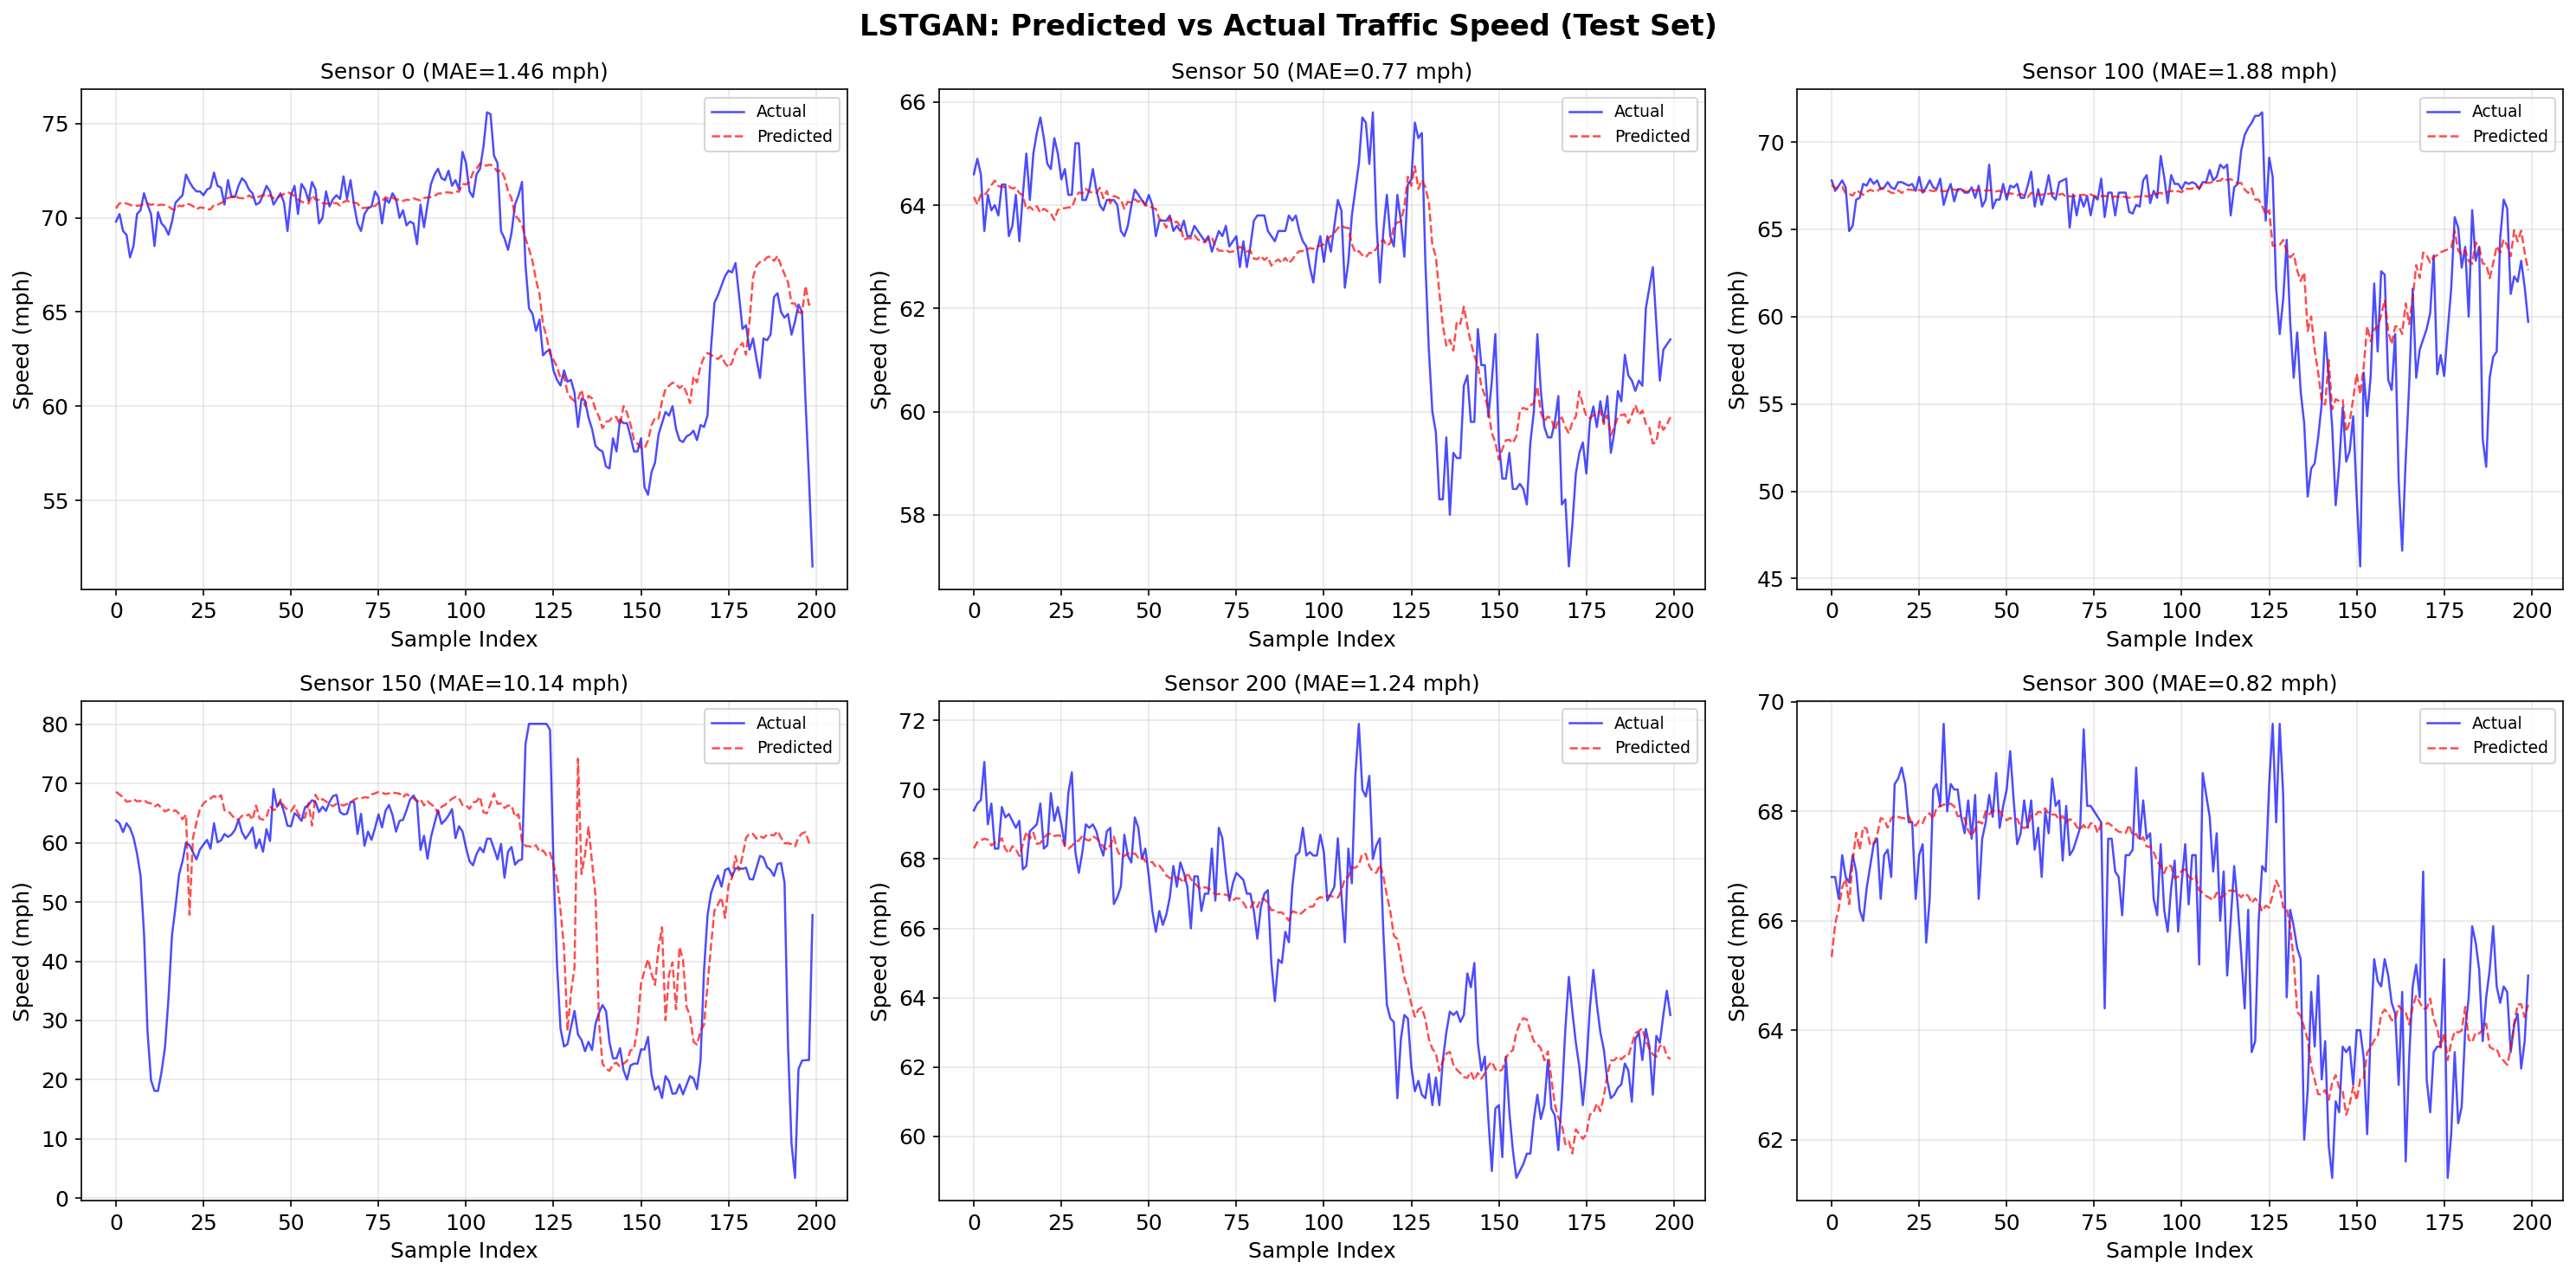

✓ Saved actual_vs_predicted.png


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('LSTGAN: Predicted vs Actual Traffic Speed (Test Set)', fontsize=16, fontweight='bold')

sensors = [0, 50, 100, 150, 200, 300]
horizon_idx = 11  # H12 = 60min ahead (hardest prediction)
sample_range = range(0, min(200, len(all_preds)))

for i, (ax, s) in enumerate(zip(axes.flat, sensors)):
    actual = all_actuals[sample_range, horizon_idx, s, 0]
    predicted = all_preds[sample_range, horizon_idx, s, 0]

    ax.plot(actual, 'b-', alpha=0.7, linewidth=1.2, label='Actual')
    ax.plot(predicted, 'r--', alpha=0.7, linewidth=1.2, label='Predicted')

    mae_s = np.mean(np.abs(actual - predicted))
    ax.set_title(f'Sensor {s} (MAE={mae_s:.2f} mph)', fontsize=12)
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Speed (mph)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved actual_vs_predicted.png')

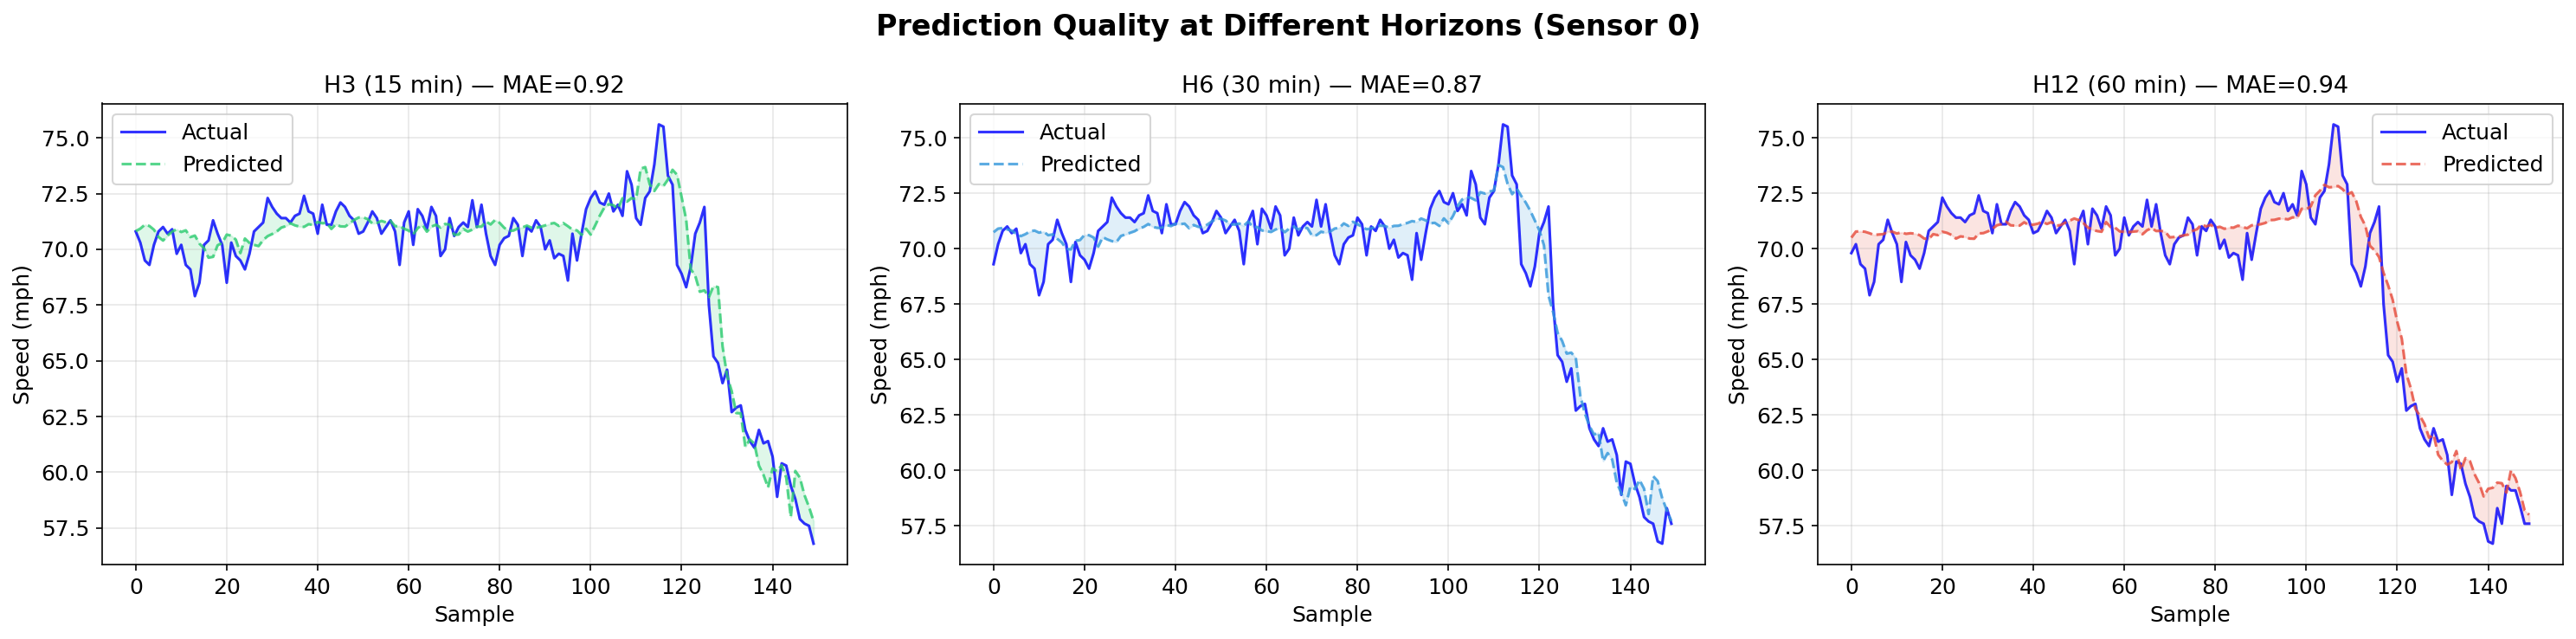

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Prediction Quality at Different Horizons (Sensor 0)', fontsize=16, fontweight='bold')

horizon_names = ['H3 (15 min)', 'H6 (30 min)', 'H12 (60 min)']
horizon_indices = [2, 5, 11]  # 0-indexed
colors = ['#2ecc71', '#3498db', '#e74c3c']
sample_range = range(0, min(150, len(all_preds)))
sensor = 0

for ax, h_idx, h_name, color in zip(axes, horizon_indices, horizon_names, colors):
    actual = all_actuals[sample_range, h_idx, sensor, 0]
    predicted = all_preds[sample_range, h_idx, sensor, 0]

    ax.plot(actual, 'b-', alpha=0.8, linewidth=1.5, label='Actual')
    ax.plot(predicted, color=color, linestyle='--', alpha=0.8, linewidth=1.5, label='Predicted')
    ax.fill_between(range(len(actual)), actual, predicted, alpha=0.15, color=color)

    mae = np.mean(np.abs(actual - predicted))
    ax.set_title(f'{h_name} — MAE={mae:.2f}', fontsize=13)
    ax.set_xlabel('Sample'); ax.set_ylabel('Speed (mph)')
    ax.legend()

plt.tight_layout()
plt.savefig('/content/multi_horizon_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

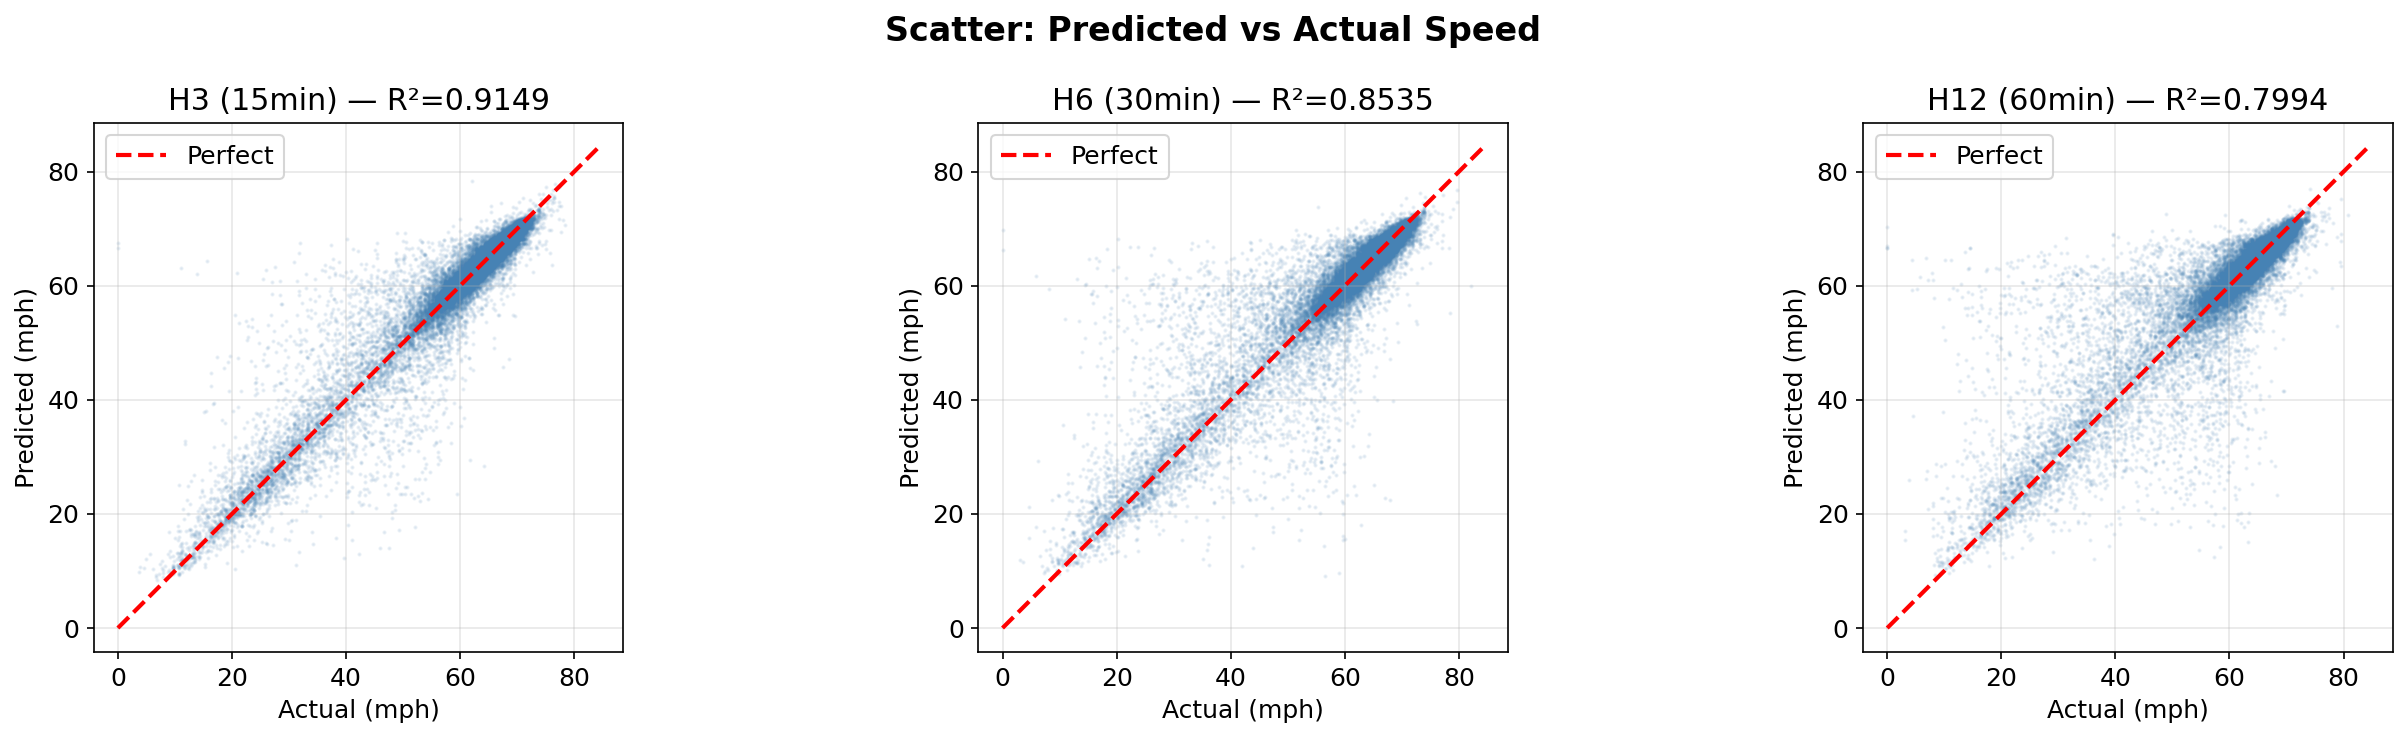

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Scatter: Predicted vs Actual Speed', fontsize=16, fontweight='bold')

for ax, h_idx, h_name in zip(axes, [2, 5, 11], ['H3 (15min)', 'H6 (30min)', 'H12 (60min)']):
    actual = all_actuals[:, h_idx, :, 0].flatten()
    predicted = all_preds[:, h_idx, :, 0].flatten()


    idx = np.random.choice(len(actual), min(50000, len(actual)), replace=False)
    ax.scatter(actual[idx], predicted[idx], s=1, alpha=0.1, c='steelblue')

    # Perfect prediction line
    mn, mx = min(actual.min(), predicted.min()), max(actual.max(), predicted.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect')

    r2 = 1 - np.sum((actual - predicted)**2) / np.sum((actual - actual.mean())**2)
    ax.set_title(f'{h_name} — R²={r2:.4f}')
    ax.set_xlabel('Actual (mph)'); ax.set_ylabel('Predicted (mph)')
    ax.legend(); ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('/content/scatter_plot.png', dpi=150, bbox_inches='tight')
plt.show()

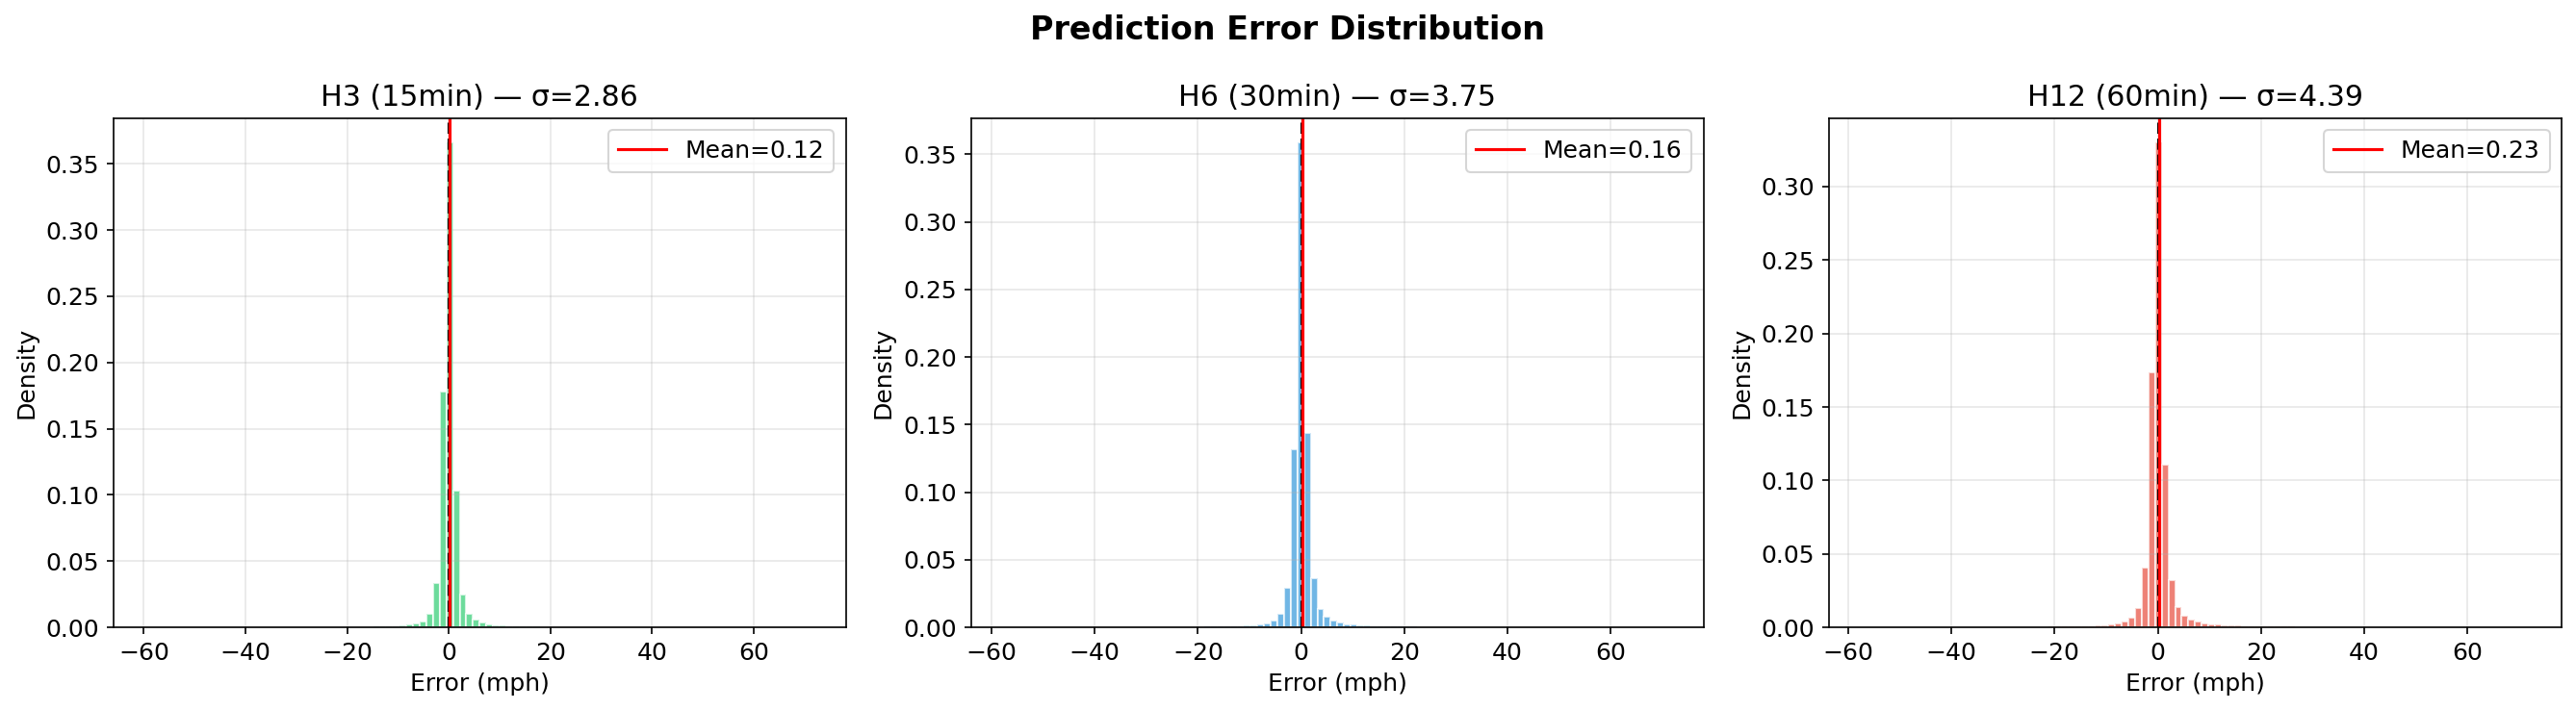

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Prediction Error Distribution', fontsize=16, fontweight='bold')

for ax, h_idx, h_name, color in zip(axes, [2, 5, 11], ['H3 (15min)', 'H6 (30min)', 'H12 (60min)'], ['#2ecc71', '#3498db', '#e74c3c']):
    errors = (all_preds[:, h_idx, :, 0] - all_actuals[:, h_idx, :, 0]).flatten()

    ax.hist(errors, bins=100, density=True, alpha=0.7, color=color, edgecolor='white')
    ax.axvline(0, color='black', linestyle='--', linewidth=1.5)

    mean_err = np.mean(errors)
    std_err = np.std(errors)
    ax.axvline(mean_err, color='red', linestyle='-', linewidth=1.5, label=f'Mean={mean_err:.2f}')

    ax.set_title(f'{h_name} — σ={std_err:.2f}')
    ax.set_xlabel('Error (mph)'); ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.savefig('/content/error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

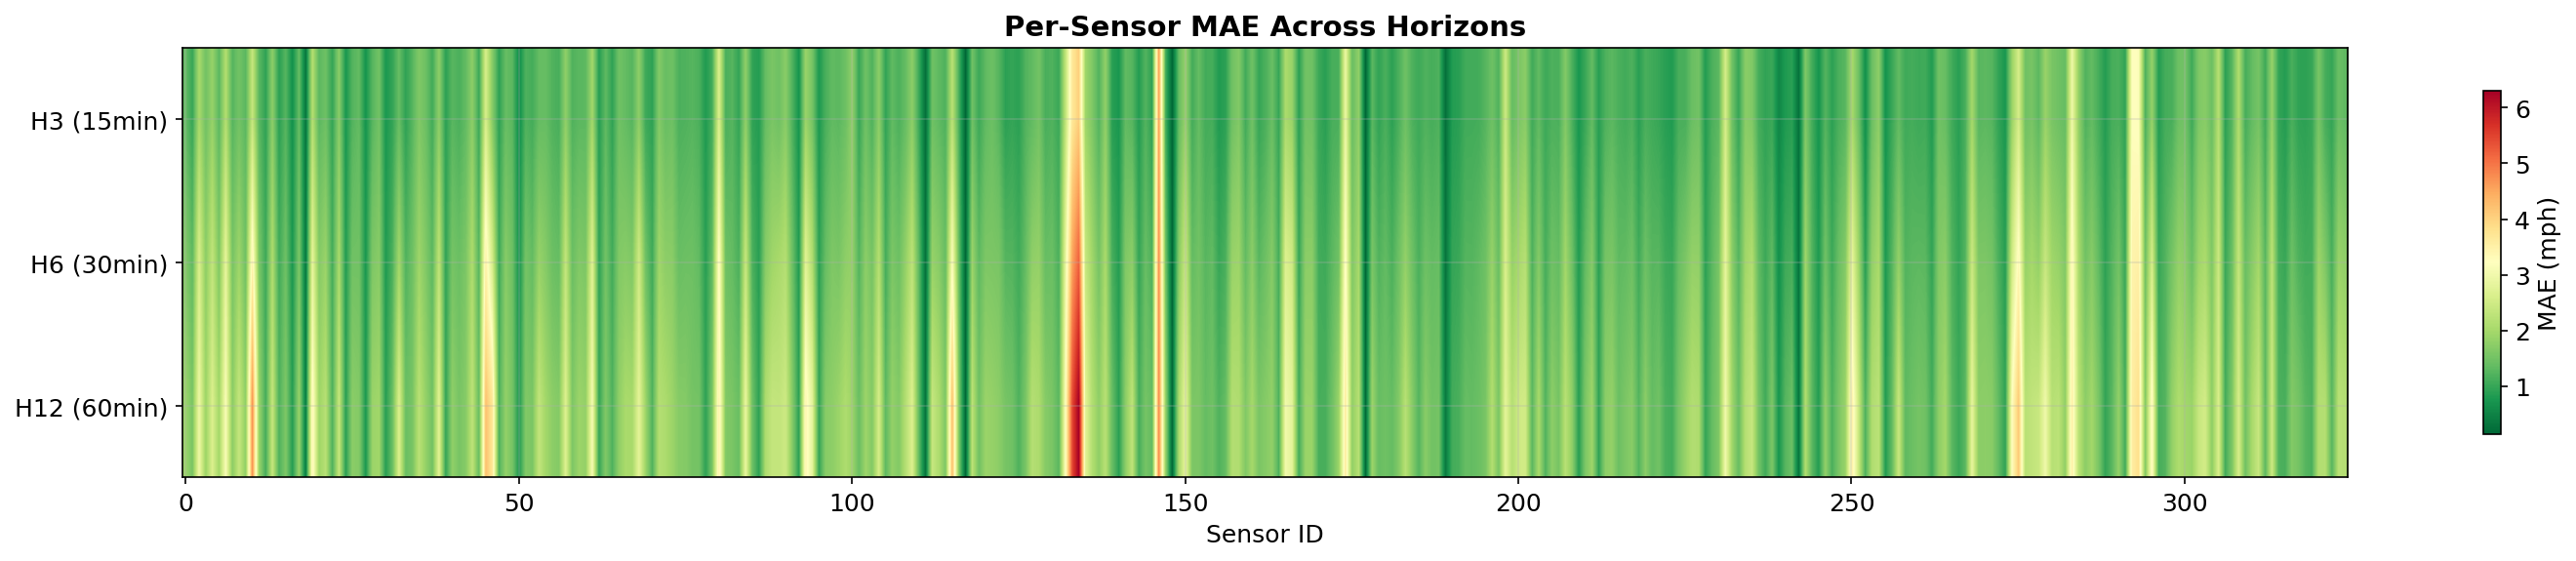

Top 5 BEST sensors:
  Sensor 148: MAE=0.146 mph
  Sensor 117: MAE=0.154 mph
  Sensor 177: MAE=0.160 mph
  Sensor 111: MAE=0.277 mph
  Sensor 242: MAE=0.299 mph

Top 5 WORST sensors:
  Sensor 134: MAE=5.180 mph
  Sensor 146: MAE=4.748 mph
  Sensor 133: MAE=4.554 mph
  Sensor 10: MAE=3.531 mph
  Sensor 293: MAE=3.508 mph


In [11]:
# Compute MAE for each sensor at each horizon
sensor_mae = np.zeros((len(EVAL_HORIZONS), NUM_SENSORS))
for i, h_idx in enumerate([2, 5, 11]):
    for s in range(NUM_SENSORS):
        sensor_mae[i, s] = np.mean(np.abs(
            all_preds[:, h_idx, s, 0] - all_actuals[:, h_idx, s, 0]
        ))

fig, ax = plt.subplots(figsize=(20, 4))
im = ax.imshow(sensor_mae, aspect='auto', cmap='RdYlGn_r', interpolation='bilinear')
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['H3 (15min)', 'H6 (30min)', 'H12 (60min)'])
ax.set_xlabel('Sensor ID')
ax.set_title('Per-Sensor MAE Across Horizons', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax, label='MAE (mph)', shrink=0.8)
plt.tight_layout()
plt.savefig('/content/sensor_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print best and worst sensors
overall_mae = sensor_mae.mean(axis=0)
best_5 = np.argsort(overall_mae)[:5]
worst_5 = np.argsort(overall_mae)[-5:][::-1]
print('Top 5 BEST sensors:')
for s in best_5:
    print(f'  Sensor {s}: MAE={overall_mae[s]:.3f} mph')
print('\nTop 5 WORST sensors:')
for s in worst_5:
    print(f'  Sensor {s}: MAE={overall_mae[s]:.3f} mph')

In [12]:
# ═══ CHANGE THIS ═══
TARGET_DATETIME = '2017-05-15 08:00:00'

test_df_loaded = pd.read_pickle(TEST_FILE)
target_ts = pd.Timestamp(TARGET_DATETIME)

time_diffs = abs(test_df_loaded.index - target_ts)
closest_idx = time_diffs.argmin()
actual_ts = test_df_loaded.index[closest_idx]

# Map to dataset sample index
dataset_idx = closest_idx - WEEKLY_WINDOW
if dataset_idx < 0 or dataset_idx >= len(test_ds):
    print(f'ERROR: Timestamp {actual_ts} is out of valid range.')
    print(f'Valid range: indices {WEEKLY_WINDOW} to {len(test_df_loaded)-FORECAST_HORIZON-1}')
else:
    # Get prediction
    sample = test_ds[dataset_idx]
    Xw, Xd, Xh, ti, Y = [s.unsqueeze(0).to(DEVICE) for s in sample]

    model.eval()
    with torch.no_grad():
        pred = model(Xw, Xd, Xh, ti, edge_index, edge_weight)

    pred_speed = (pred.cpu().numpy() * train_std + train_mean)[0, :, :, 0]  # (12, 325)
    actual_speed = (Y.cpu().numpy() * train_std + train_mean)[0, :, :, 0]   # (12, 325)

    print(f'Prediction at: {actual_ts}')
    print(f'Forecasting {FORECAST_HORIZON} steps ({FORECAST_HORIZON*5} minutes) ahead')
    print(f'\n{"Horizon":<12} {"Sensor 0":>10} {"Sensor 100":>12} {"Sensor 200":>12} {"Sensor 300":>12}')
    print('-' * 60)
    for h in range(FORECAST_HORIZON):
        mins = (h+1) * 5
        print(f'{mins:>3}min ahead  '
              f'{pred_speed[h,0]:>10.1f}  {pred_speed[h,100]:>10.1f}  '
              f'{pred_speed[h,200]:>10.1f}  {pred_speed[h,300]:>10.1f}')

    # Plot for all sensors at this timestamp
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Predictions at {actual_ts}', fontsize=16, fontweight='bold')
    for i, (ax, s) in enumerate(zip(axes.flat, [0, 50, 100, 150, 200, 300])):
        steps = np.arange(1, FORECAST_HORIZON+1) * 5
        ax.plot(steps, actual_speed[:, s], 'bo-', linewidth=2, markersize=6, label='Actual')
        ax.plot(steps, pred_speed[:, s], 'r^--', linewidth=2, markersize=6, label='Predicted')
        ax.set_title(f'Sensor {s}')
        ax.set_xlabel('Minutes Ahead'); ax.set_ylabel('Speed (mph)')
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('/content/specific_time_prediction.png', dpi=150, bbox_inches='tight')
    plt.show()

ERROR: Timestamp 2017-05-25 19:20:00 is out of valid range.
Valid range: indices 2016 to 10411


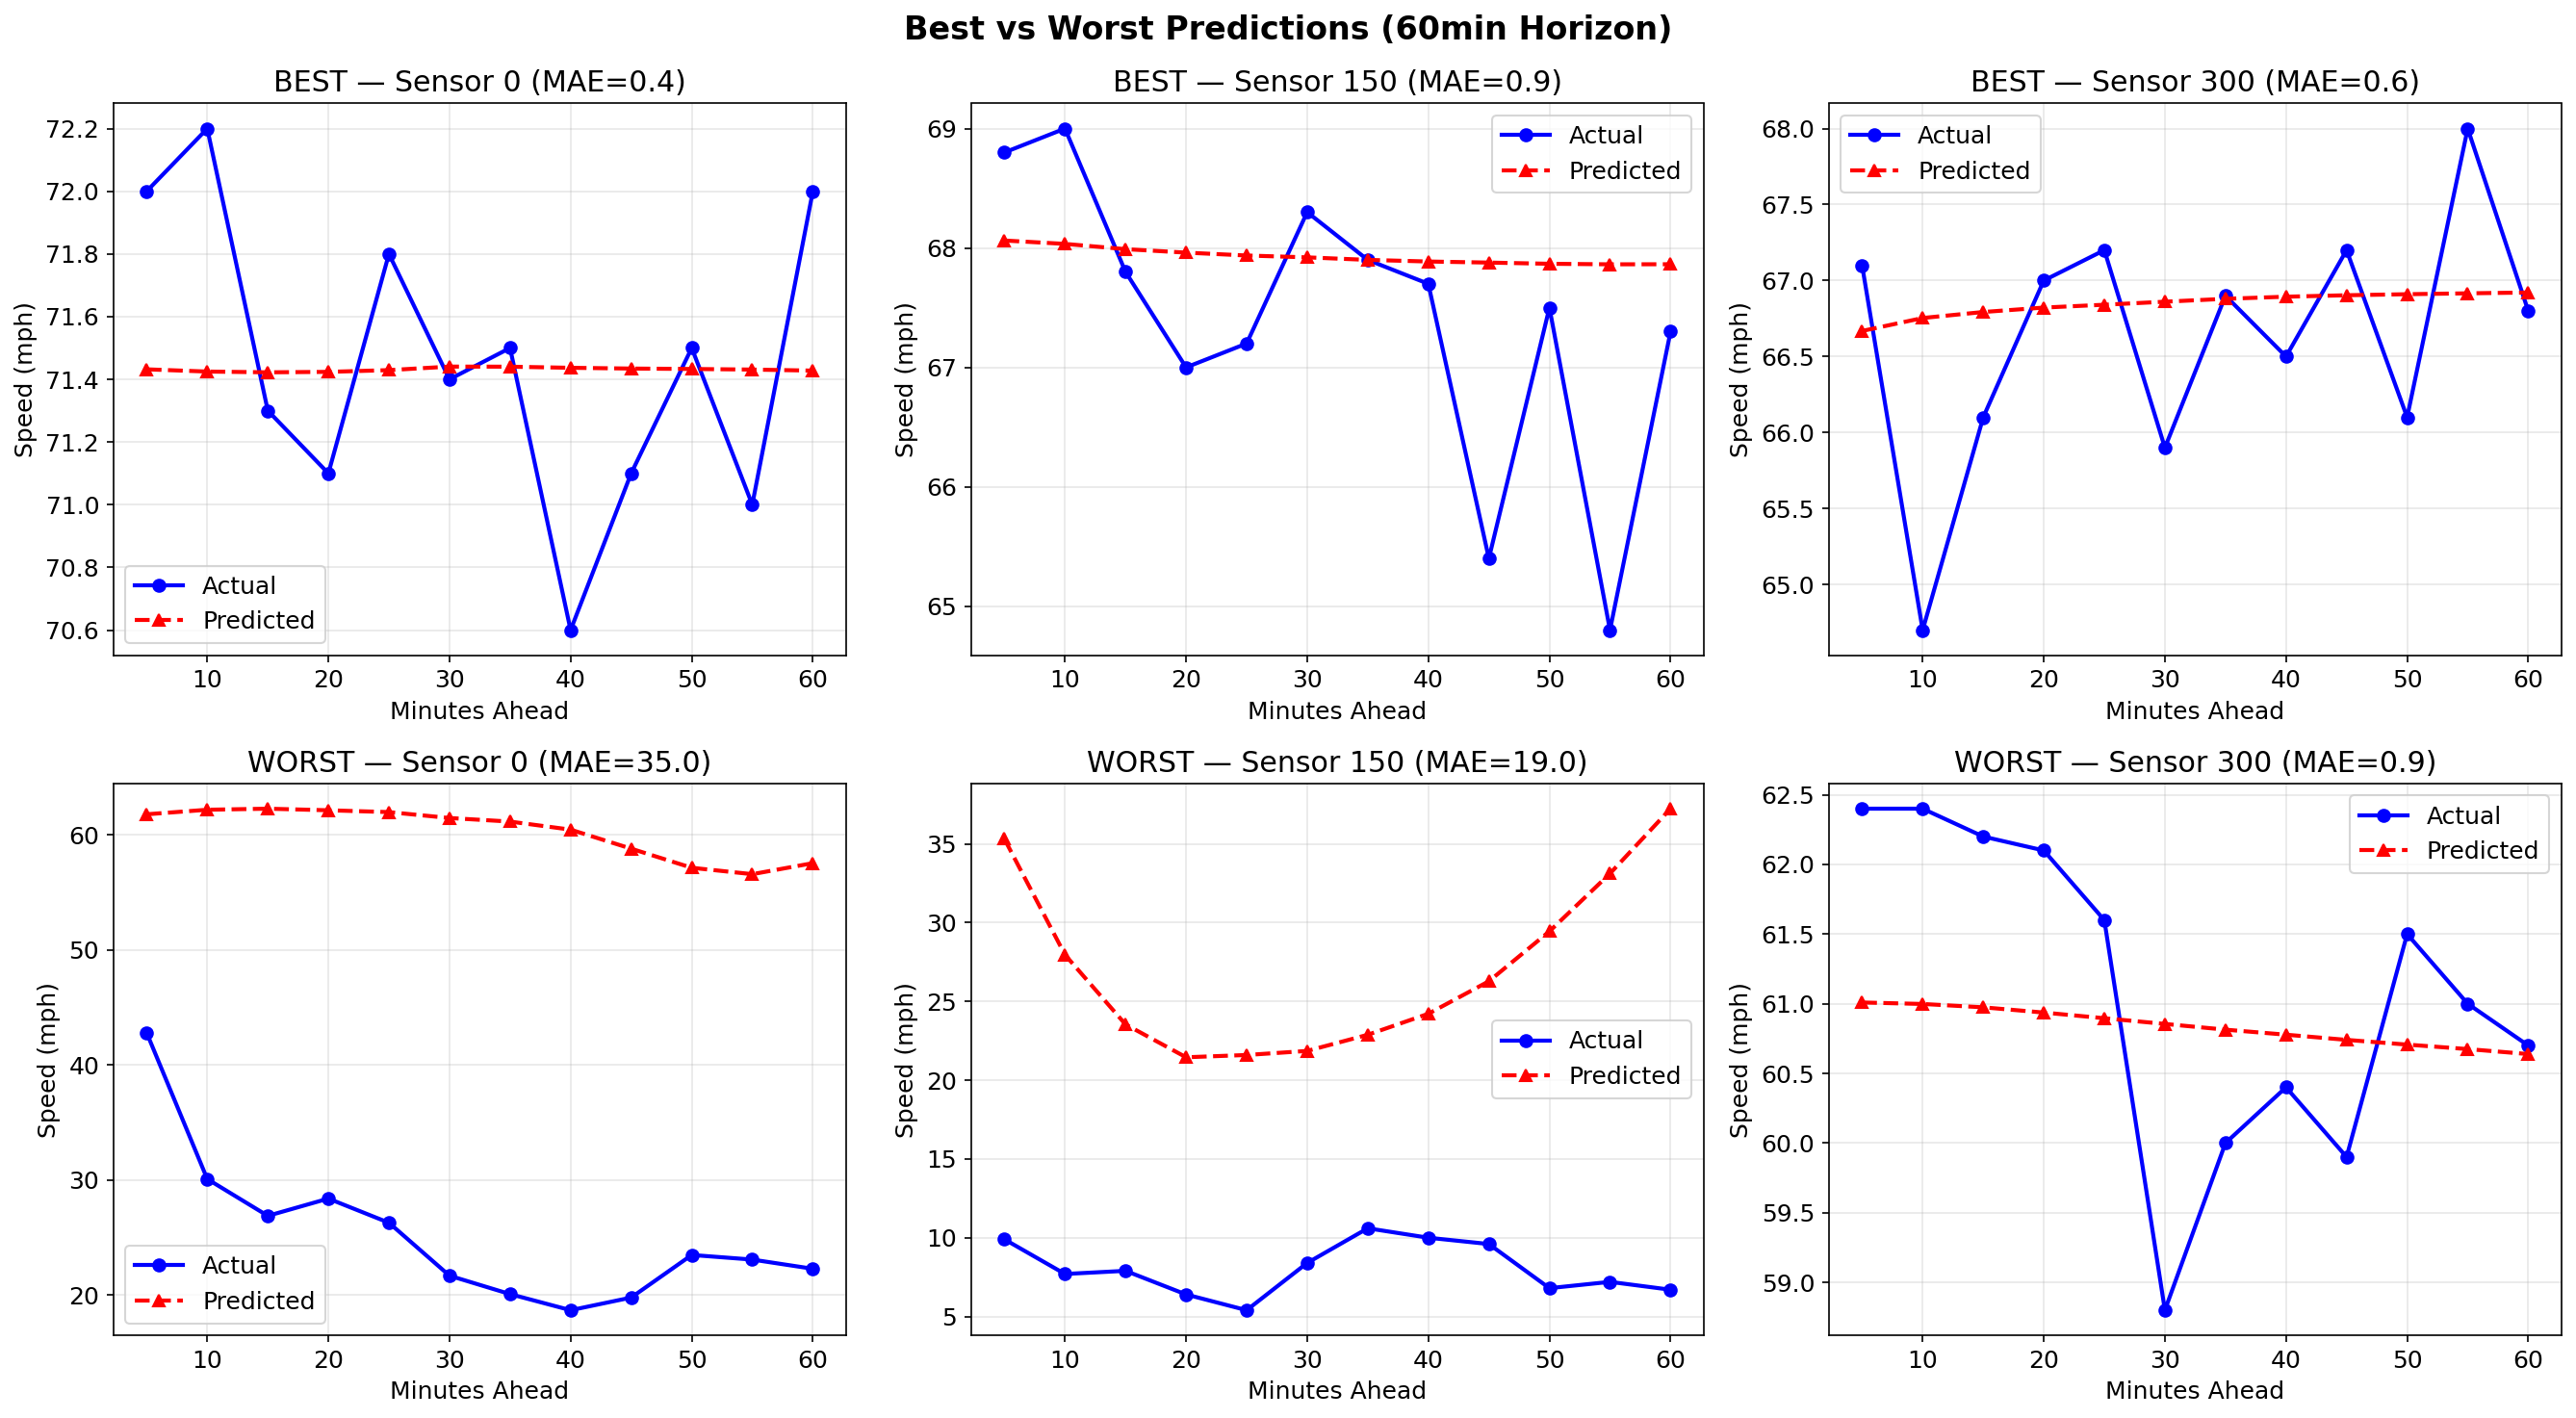

Best sample index: 698, MAE=0.568 mph
Worst sample index: 5339, MAE=6.722 mph


In [13]:
sample_maes = np.mean(np.abs(all_preds[:,:,:,0] - all_actuals[:,:,:,0]), axis=(1,2))
worst_idx = np.argmax(sample_maes)
best_idx  = np.argmin(sample_maes)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Best vs Worst Predictions (60min Horizon)', fontsize=16, fontweight='bold')

for row, (idx, label) in enumerate([(best_idx, 'BEST'), (worst_idx, 'WORST')]):
    for col, s in enumerate([0, 150, 300]):
        ax = axes[row, col]
        actual = all_actuals[idx, :, s, 0]
        predicted = all_preds[idx, :, s, 0]
        steps = np.arange(1, FORECAST_HORIZON+1) * 5

        ax.plot(steps, actual, 'bo-', linewidth=2, label='Actual')
        ax.plot(steps, predicted, 'r^--', linewidth=2, label='Predicted')
        mae = np.mean(np.abs(actual - predicted))
        ax.set_title(f'{label} — Sensor {s} (MAE={mae:.1f})')
        ax.set_xlabel('Minutes Ahead'); ax.set_ylabel('Speed (mph)')
        ax.legend()

plt.tight_layout()
plt.savefig('/content/best_worst_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best sample index: {best_idx}, MAE={sample_maes[best_idx]:.3f} mph')
print(f'Worst sample index: {worst_idx}, MAE={sample_maes[worst_idx]:.3f} mph')

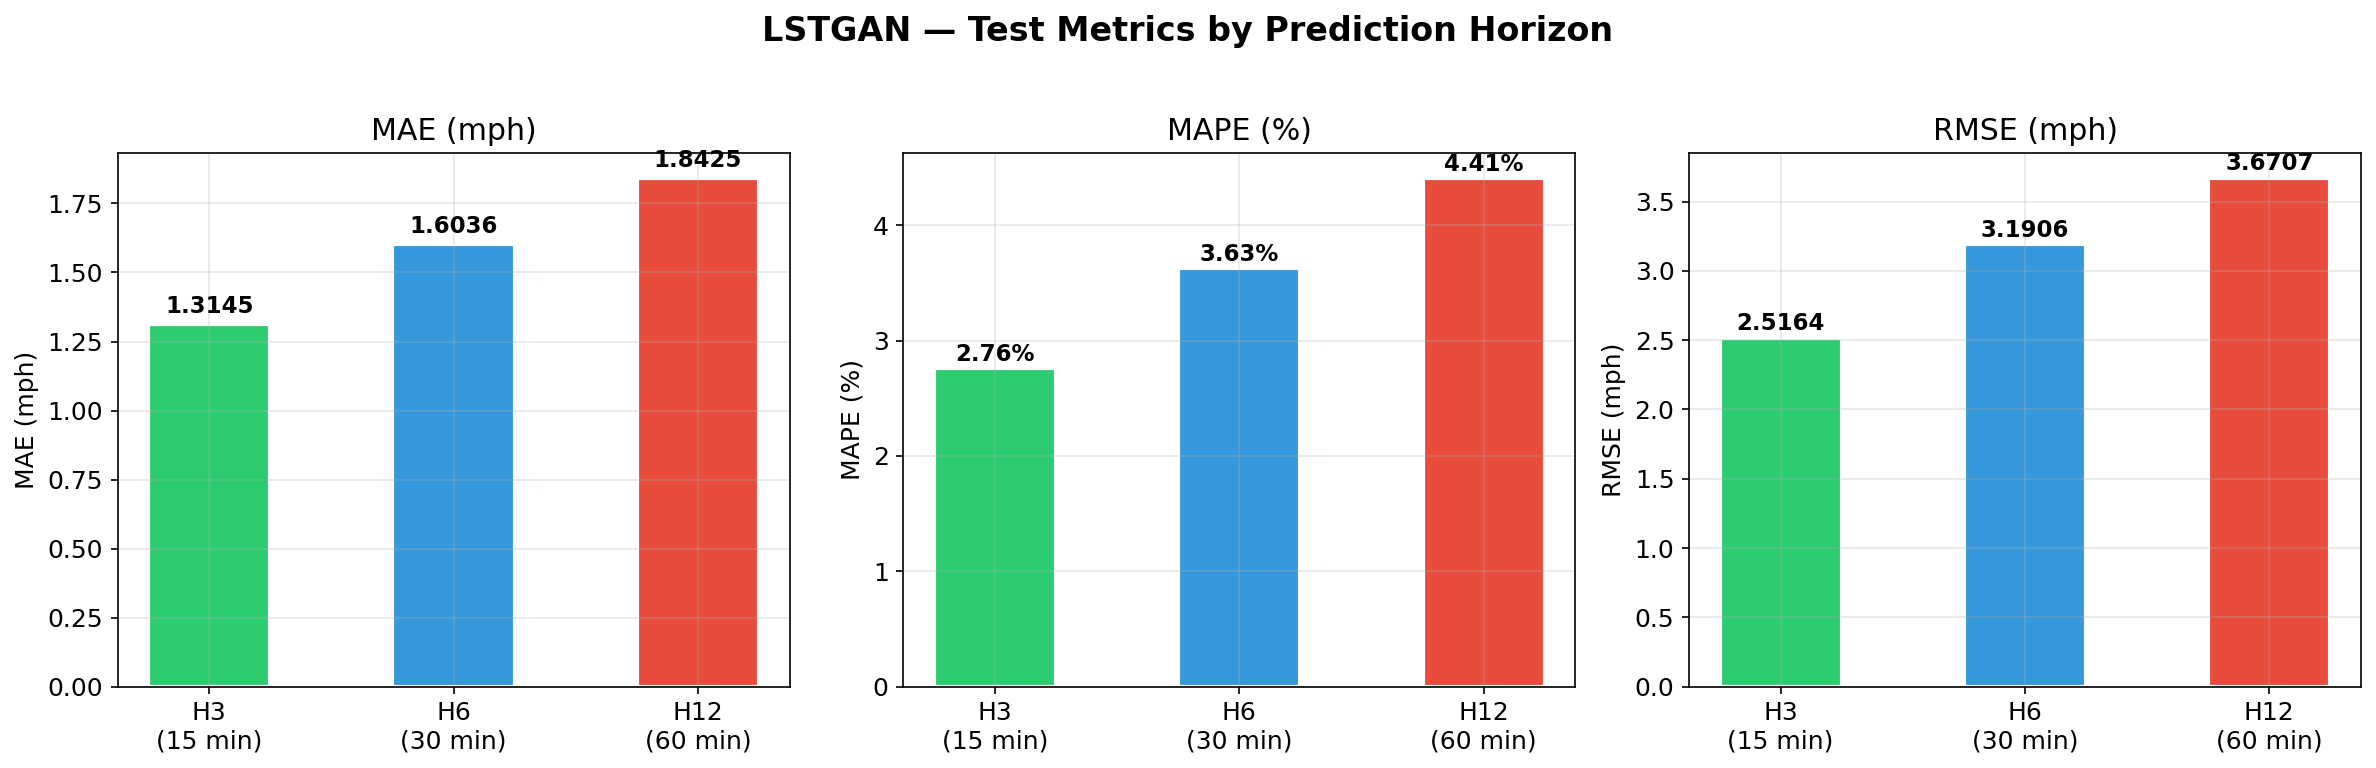

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('LSTGAN — Test Metrics by Prediction Horizon', fontsize=16, fontweight='bold', y=1.02)

horizon_labels = ['H3\n(15 min)', 'H6\n(30 min)', 'H12\n(60 min)']
colors = ['#2ecc71', '#3498db', '#e74c3c']

for ax, metric, ylabel in zip(axes, ['mae', 'mape', 'rmse'], ['MAE (mph)', 'MAPE (%)', 'RMSE (mph)']):
    vals = [hr[h][metric] for h in EVAL_HORIZONS]
    bars = ax.bar(horizon_labels, vals, color=colors, edgecolor='white', linewidth=2, width=0.5)
    for bar, v in zip(bars, vals):
        label = f'{v:.2f}%' if metric == 'mape' else f'{v:.4f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                label, ha='center', va='bottom', fontweight='bold', fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)

plt.tight_layout()
plt.savefig('/content/horizon_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

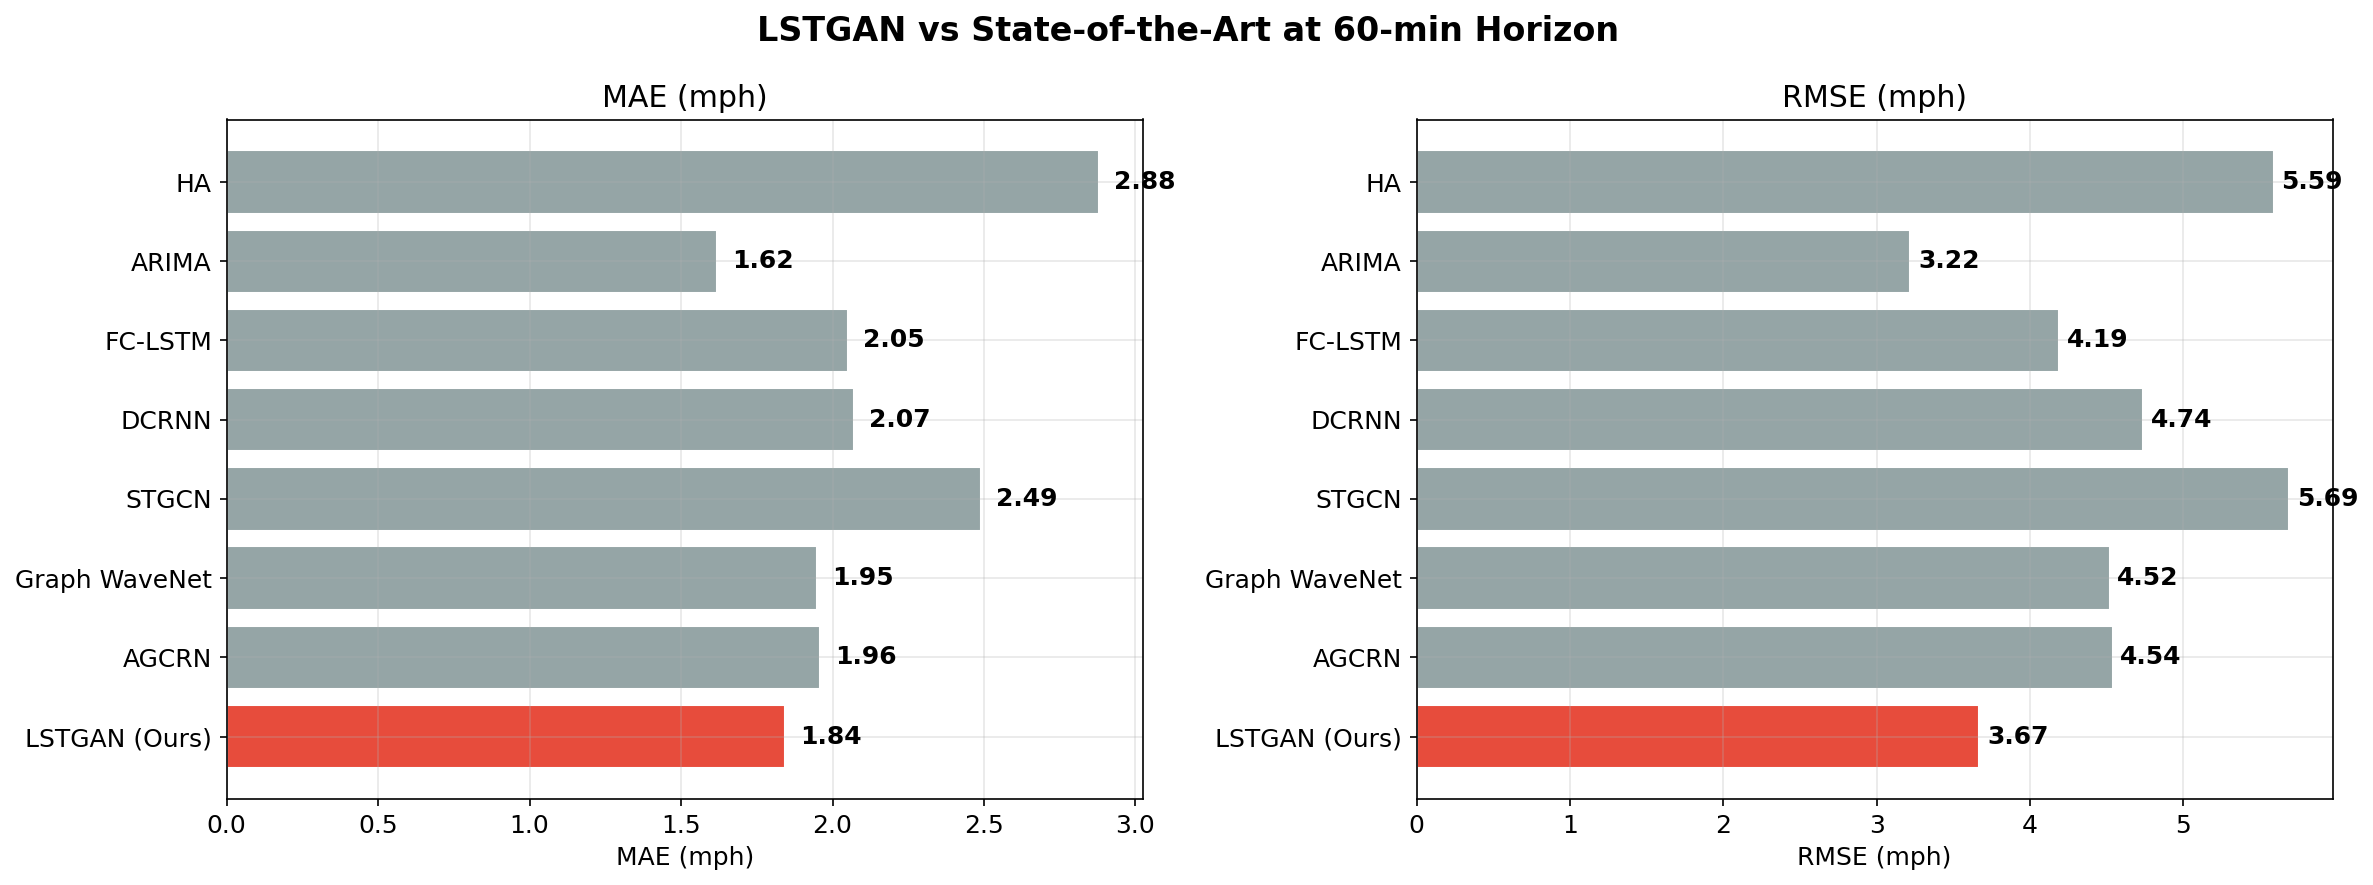

In [15]:
benchmarks = {
    'HA':           {'60min': {'MAE': 2.88, 'RMSE': 5.59}},
    'ARIMA':        {'60min': {'MAE': 1.62, 'RMSE': 3.22}},
    'FC-LSTM':      {'60min': {'MAE': 2.05, 'RMSE': 4.19}},
    'DCRNN':        {'15min': {'MAE': 1.38, 'RMSE': 2.95}, '30min': {'MAE': 1.74, 'RMSE': 3.97}, '60min': {'MAE': 2.07, 'RMSE': 4.74}},
    'STGCN':        {'15min': {'MAE': 1.36, 'RMSE': 2.96}, '30min': {'MAE': 1.81, 'RMSE': 4.27}, '60min': {'MAE': 2.49, 'RMSE': 5.69}},
    'Graph WaveNet': {'15min': {'MAE': 1.30, 'RMSE': 2.74}, '30min': {'MAE': 1.63, 'RMSE': 3.70}, '60min': {'MAE': 1.95, 'RMSE': 4.52}},
    'AGCRN':        {'15min': {'MAE': 1.37, 'RMSE': 2.87}, '30min': {'MAE': 1.69, 'RMSE': 3.85}, '60min': {'MAE': 1.96, 'RMSE': 4.54}},
}

our = {
    '15min': {'MAE': hr[3]['mae'], 'RMSE': hr[3]['rmse']},
    '30min': {'MAE': hr[6]['mae'], 'RMSE': hr[6]['rmse']},
    '60min': {'MAE': hr[12]['mae'], 'RMSE': hr[12]['rmse']},
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('LSTGAN vs State-of-the-Art at 60-min Horizon', fontsize=16, fontweight='bold')

models_60 = {k: v['60min'] for k, v in benchmarks.items() if '60min' in v}
models_60['LSTGAN (Ours)'] = our['60min']

names = list(models_60.keys())
mae_vals = [models_60[n]['MAE'] for n in names]
rmse_vals = [models_60[n]['RMSE'] for n in names]

colors_bar = ['#95a5a6'] * (len(names)-1) + ['#e74c3c']

for ax, vals, title in zip(axes, [mae_vals, rmse_vals], ['MAE (mph)', 'RMSE (mph)']):
    bars = ax.barh(names, vals, color=colors_bar, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f'{v:.2f}', va='center', fontweight='bold')
    ax.set_xlabel(title)
    ax.set_title(title)
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('/content/sota_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
print('  LSTGAN COMPLETE ANALYSIS SUMMARY')
print(f'  Model Parameters: {n_params:,}')
print(f'  Checkpoint Epoch: {ckpt["epoch"]}')
print(f'  Train Mean: {train_mean:.2f} mph')
print(f'  Train Std:  {train_std:.2f} mph')
print()
print(f'  Overall Test: MAE={test_mae:.4f} | MAPE={test_mape:.2f}% | RMSE={test_rmse:.4f}')
print()
for h in EVAL_HORIZONS:
    r = hr[h]
    print(f'  H{h:2d} ({h*5:2d}min): MAE={r["mae"]:.4f} | MAPE={r["mape"]:.2f}% | RMSE={r["rmse"]:.4f}')
print()
print('  Saved visualizations:')
for f in ['actual_vs_predicted.png', 'multi_horizon_comparison.png',
          'scatter_plot.png', 'error_distribution.png', 'sensor_heatmap.png',
          'specific_time_prediction.png', 'best_worst_analysis.png',
          'horizon_metrics.png', 'sota_comparison.png']:
    print(f'    /content/{f}')

  LSTGAN COMPLETE ANALYSIS SUMMARY
  Model Parameters: 109,428
  Checkpoint Epoch: 50
  Train Mean: 62.74 mph
  Train Std:  9.44 mph

  Overall Test: MAE=1.5369 | MAPE=3.47% | RMSE=3.1188

  H 3 (15min): MAE=1.3145 | MAPE=2.76% | RMSE=2.5164
  H 6 (30min): MAE=1.6036 | MAPE=3.63% | RMSE=3.1906
  H12 (60min): MAE=1.8425 | MAPE=4.41% | RMSE=3.6707

  Saved visualizations:
    /content/actual_vs_predicted.png
    /content/multi_horizon_comparison.png
    /content/scatter_plot.png
    /content/error_distribution.png
    /content/sensor_heatmap.png
    /content/specific_time_prediction.png
    /content/best_worst_analysis.png
    /content/horizon_metrics.png
    /content/sota_comparison.png
